In [1]:
from functools import partial
import os

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap
from jax import random
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import seaborn as sns

In [2]:
os.makedirs('figures', exist_ok=True)
os.makedirs('logs', exist_ok=True)
sns.set_theme(style="darkgrid")

In [ ]:
d = 20  # dimension
n_data = 500  # number of data points
m_teach = 15  # number of teacher neurons

key = random.PRNGKey(0)
key, subkey1, subkey2, subkey3, subkey4 = random.split(key, 5)

# Data generation
X = random.normal(subkey1, (d, n_data))
W1_teach = random.normal(subkey2, (m_teach, d)) / jnp.sqrt(d)
W2_teach = random.normal(subkey3, (1, m_teach))

In [4]:
def relu(x):
    return jnp.maximum(x, 0)

Y_teach = (W2_teach @ relu(W1_teach @ X)) / jnp.sqrt(m_teach)

# Validation data
X_val = random.normal(subkey4, (d, n_data))
Y_teach_val = (W2_teach @ relu(W1_teach @ X_val)) / jnp.sqrt(m_teach)

In [5]:
@jit
def forward(W1, W2, x):
    H = relu(W1 @ x)
    return (W2 @ H) / W1.shape[0]

@jit
def loss_fn(W1, W2, x, y):
    return 0.5 * jnp.mean((forward(W1, W2, x) - y)**2)

@jit
def grad_forward(W1, W2, x, mask):  # implements df/dW1, df/dW2
    m = W1.shape[0]
    dW1 = jnp.outer(jnp.maximum(jnp.sign(W1 @ x), 0) * W2 * mask, x) / m
    dW2 = mask * jnp.maximum(W1 @ x, 0) / m
    return dW1, dW2

@jit
def grad_forward_backward(W1, W2, x, y, for_mask, back_mask):
    dl_df = forward(for_mask.T * W1, W2, x) - y
    df_dW1, df_dW2 = grad_forward(W1, W2, x, back_mask)
    dW1 = dl_df * df_dW1
    dW2 = dl_df * df_dW2
    return dW1, dW2

batched_grad_fb = vmap(
    grad_forward_backward, in_axes=[None, None, 1, 1, None, None], out_axes=(0, 0)
)

@jit
def grad_fb(W1, W2, X, Y, for_mask, back_mask):
    dW1, dW2 = batched_grad_fb(W1, W2, X, Y, for_mask, back_mask)
    return jnp.mean(dW1, axis=0), jnp.mean(dW2, axis=0)

In [6]:
@partial(jax.jit, static_argnames=["m", "variant"])
def iteration(key, W1, W2, X, X_val, Y_teach, Y_teach_val, m, eta, p, variant):
    key1, key2 = random.split(key, 2)
    full_mask = jnp.ones((1, m))
    dropout_mask1 = random.bernoulli(key1, 1.0 - p, (1, m)) / (1.0 - p)
    dropout_mask2 = random.bernoulli(key2, 1.0 - p, (1, m)) / (1.0 - p)

    if variant == "dropout":
        loss = loss_fn(dropout_mask1.T * W1, W2, X, Y_teach)
        grads_W1, grads_W2 = grad_fb(W1, W2, X, Y_teach, dropout_mask1, dropout_mask1)
    elif variant == "RaM":
        loss = loss_fn(W1, W2, X, Y_teach)
        grads_W1, grads_W2 = grad_fb(W1, W2, X, Y_teach, full_mask, dropout_mask1)
    elif variant == "PN + RaM":
        loss = loss_fn(dropout_mask2.T * W1, W2, X, Y_teach)
        grads_W1, grads_W2 = grad_fb(W1, W2, X, Y_teach, dropout_mask2, dropout_mask1)
    elif variant == "no dropout":
        loss = loss_fn(W1, W2, X, Y_teach)
        grads_W1, grads_W2 = grad_fb(W1, W2, X, Y_teach, full_mask, full_mask)
    W1 = W1 - eta * grads_W1
    W2 = W2 - eta * grads_W2   

    val_loss = loss_fn(W1, W2, X_val, Y_teach_val)
    
    return loss, val_loss, W1, W2

In [7]:
def GD(key, X, X_val, Y_teach, Y_teach_val, m, eta, p, niter, variant):
    d, _ = X.shape
    key, k1, k2 = random.split(key, 3)
    W1 = random.normal(k1, (m, d)) / jnp.sqrt(d)
    W2 = random.normal(k2, (1, m))

    loss_logs = {"m": [],
                "Step": [],
                "Train loss": [],
                "Test loss": [],
                "Variant": [],
                }
    W1s = [W1]
    W2s = [W2]

    for t in range(niter+1):
        key, subkey = random.split(key)
        loss, test_loss, W1, W2 = iteration(subkey, W1, W2, X, X_val, Y_teach, Y_teach_val, m, eta, p, variant)
        loss_logs["m"].append(m)
        loss_logs["Step"].append(t)
        loss_logs["Train loss"].append(loss.item())
        loss_logs["Test loss"].append(test_loss.item())
        loss_logs["Variant"].append(variant)
        W1s.append(W1)
        W2s.append(W2)

    return loss_logs, {"W1s": jnp.stack(W1s), "W2s": jnp.stack(W2s)}

In [15]:
def plots_trajectory_2d(trajs_plain, trajs_ram, trajs_dropout, trajs_forback, kbegin, kend, n_neurons):
    for idx_neuron in range(n_neurons):
        plt.plot([trajs_dropout["W1s"][k, idx_neuron, 0] for k in range(kbegin, kend)], [trajs_dropout["W1s"][k, idx_neuron, 1] for k in range(kbegin, kend)], label="dropout", color=sns.color_palette()[0])
        plt.plot([trajs_plain["W1s"][k, idx_neuron, 0] for k in range(kbegin, kend)], [trajs_plain["W1s"][k][idx_neuron, 1] for k in range(kbegin, kend)], label="no dropout", color=sns.color_palette()[1])
        plt.plot([trajs_ram["W1s"][k, idx_neuron, 0] for k in range(kbegin, kend)], [trajs_ram["W1s"][k, idx_neuron, 1] for k in range(kbegin, kend)], label="RaM", color=sns.color_palette()[2])
        plt.plot(trajs_dropout["W1s"][0, idx_neuron, 0], trajs_dropout["W1s"][0, idx_neuron, 1], 'ko')
        plt.legend()
        plt.savefig("figures/neuron_trajectory_without_forback_{}.pdf".format(idx_neuron), bbox_inches="tight")
        plt.plot([trajs_forback["W1s"][k, idx_neuron, 0] for k in range(kbegin, kend)], [trajs_forback["W1s"][k, idx_neuron, 1] for k in range(kbegin, kend)], label="PN + RaM", color=sns.color_palette()[3])
        plt.legend()
        plt.savefig("figures/neuron_trajectory_with_forback_{}.pdf".format(idx_neuron), bbox_inches="tight")
        plt.close()

In [17]:
# Experiment settings
p = 0.3
niter = 1_000
list_m = [200, 500, 1_000, 2_000, 5_000]
master_eta = 0.5
n_repeats = 10
m_keys = random.split(key, len(list_m))
first_exp = True

for m_key, m in zip(m_keys, list_m):
    eta = master_eta * m
    repeat_keys = random.split(m_key, n_repeats)
    
    for (repeat_idx, repeat_key) in enumerate(repeat_keys):
        print("Starting exp {}/{} with n={}".format(repeat_idx+1, n_repeats, m))
    
        # Run all three variants with the same random key
        loss_logs_plain, trajs_plain = GD(repeat_key, X, X_val, Y_teach, Y_teach_val, m, eta, p, niter, variant="no dropout")
        loss_logs_ram, trajs_ram = GD(repeat_key, X, X_val, Y_teach, Y_teach_val, m, eta, p, niter, variant="RaM")
        loss_logs_dropout, trajs_dropout = GD(repeat_key, X, X_val, Y_teach, Y_teach_val, m, eta, p, niter, variant="dropout")
        loss_logs_forback, trajs_forback = GD(repeat_key, X, X_val, Y_teach, Y_teach_val, m, eta, p, niter, variant="PN + RaM")

        # Post-process results to prepare seaborn plots
        distance_logs = {"m": [],
                "Step": [],
                "RMS distance": [],
                "Variant": [],
            }

        for i in range(niter):
            distance_logs["m"].append(m)
            distance_logs["Step"].append(i)
            distance_logs["RMS distance"].append(np.sqrt(np.mean(np.sum((trajs_dropout["W1s"][i] - trajs_plain["W1s"][i])**2, axis=1), axis=0).item() + np.mean((trajs_dropout["W2s"][i] - trajs_plain["W2s"][i])**2).item()))
            distance_logs["Variant"].append("no dropout")
            
            distance_logs["m"].append(m)
            distance_logs["Step"].append(i)
            distance_logs["RMS distance"].append(np.sqrt(np.mean(np.sum((trajs_dropout["W1s"][i] - trajs_ram["W1s"][i])**2, axis=1), axis=0).item() + np.mean((trajs_dropout["W2s"][i] - trajs_ram["W2s"][i])**2).item()))
            distance_logs["Variant"].append("RaM")
            
            distance_logs["m"].append(m)
            distance_logs["Step"].append(i)
            distance_logs["RMS distance"].append(np.sqrt(np.mean(np.sum((trajs_dropout["W1s"][i] - trajs_forback["W1s"][i])**2, axis=1), axis=0).item() + np.mean((trajs_dropout["W2s"][i] - trajs_forback["W2s"][i])**2).item()))
            distance_logs["Variant"].append("PN + RaM")

        if first_exp:
            loss_df = pd.DataFrame(loss_logs_plain)
            distance_df = pd.DataFrame(distance_logs)
            first_exp = False
        else:
            loss_df =pd.concat([loss_df, pd.DataFrame(loss_logs_plain)])
            distance_df = pd.concat([distance_df, pd.DataFrame(distance_logs)])
        loss_df = pd.concat([loss_df, pd.DataFrame(loss_logs_ram)])
        loss_df = pd.concat([loss_df, pd.DataFrame(loss_logs_dropout)])
        loss_df = pd.concat([loss_df, pd.DataFrame(loss_logs_forback)])
        
        # Plot trajectories (projection over first 2 coordinates) for one of the experiments
        if m == 5000 and repeat_idx == 0:
            print("Plotting trajectories")
            plots_trajectory_2d(trajs_plain, trajs_ram, trajs_dropout, trajs_forback, 0, niter, 3)

Starting exp 1/10 with n=200
Starting exp 2/10 with n=200
Starting exp 3/10 with n=200
Starting exp 4/10 with n=200
Starting exp 5/10 with n=200
Starting exp 6/10 with n=200
Starting exp 7/10 with n=200
Starting exp 8/10 with n=200
Starting exp 9/10 with n=200
Starting exp 10/10 with n=200
Starting exp 1/10 with n=500
Starting exp 2/10 with n=500
Starting exp 3/10 with n=500
Starting exp 4/10 with n=500
Starting exp 5/10 with n=500
Starting exp 6/10 with n=500
Starting exp 7/10 with n=500
Starting exp 8/10 with n=500
Starting exp 9/10 with n=500
Starting exp 10/10 with n=500
Starting exp 1/10 with n=1000
Starting exp 2/10 with n=1000
Starting exp 3/10 with n=1000
Starting exp 4/10 with n=1000
Starting exp 5/10 with n=1000
Starting exp 6/10 with n=1000
Starting exp 7/10 with n=1000
Starting exp 8/10 with n=1000
Starting exp 9/10 with n=1000
Starting exp 10/10 with n=1000
Starting exp 1/10 with n=2000
Starting exp 2/10 with n=2000
Starting exp 3/10 with n=2000
Starting exp 4/10 with n=20

In [ ]:
#with open('logs/teacher_student_dropout_loss_df.pkl', 'rb') as handle:
#    loss_df = pickle.load(handle)
#with open('logs/teacher_student_dropout_distance_df.pkl', 'rb') as handle:
#    distance_df = pickle.load(handle)

In [18]:
with open('logs/teacher_student_dropout_loss_df.pkl', 'wb') as handle:
    pickle.dump(loss_df, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('logs/teacher_student_dropout_distance_df.pkl', 'wb') as handle:
    pickle.dump(distance_df, handle, protocol=pickle.HIGHEST_PROTOCOL)

Train loss, m=200


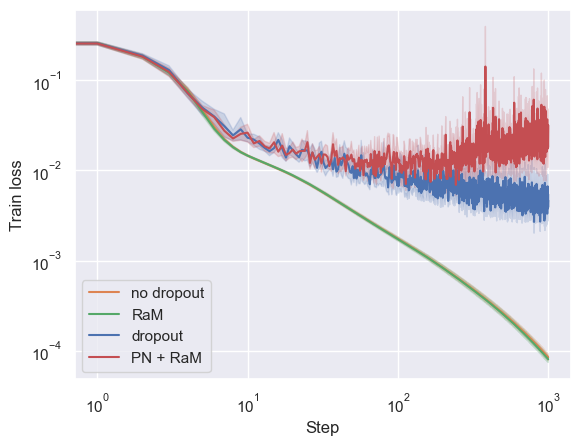

Train loss, m=5000


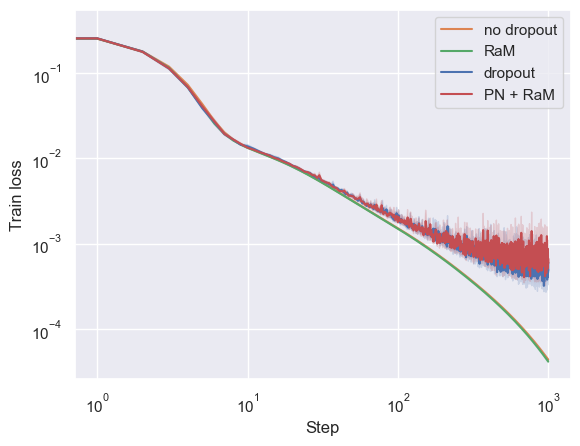

In [11]:
# Plotting the train loss
for m in [200, 5_000]:
    print("Train loss, m={}".format(m))
    sns.lineplot(loss_df[loss_df["m"]==m], x="Step", y="Train loss", hue="Variant", palette=[sns.color_palette()[1], sns.color_palette()[2], sns.color_palette()[0], sns.color_palette()[3]])
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.savefig("figures/train_loss_m={}.pdf".format(m), bbox_inches="tight")
    plt.show()

Test loss, m=200


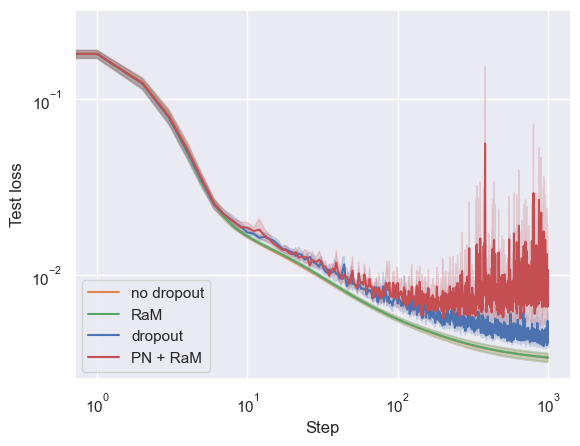

Test loss, m=5000


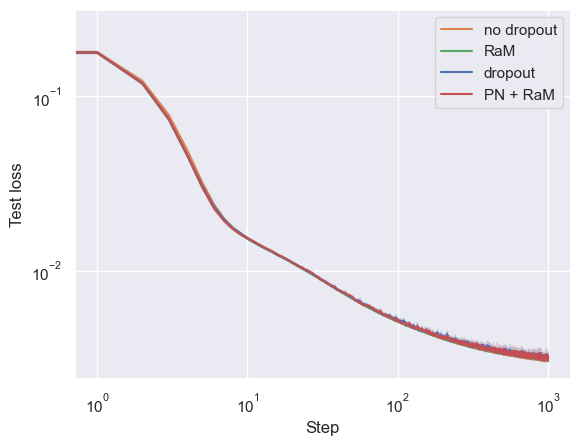

In [12]:
# Plotting the test loss
for m in [200, 5_000]:
    print("Test loss, m={}".format(m))
    sns.lineplot(loss_df[loss_df["m"]==m], x="Step", y="Test loss", hue="Variant", palette=[sns.color_palette()[1], sns.color_palette()[2], sns.color_palette()[0], sns.color_palette()[3]])
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.savefig("figures/test_loss_m={}.pdf".format(m), bbox_inches="tight")
    plt.show()

## Distance between trajectories

### As a function of time

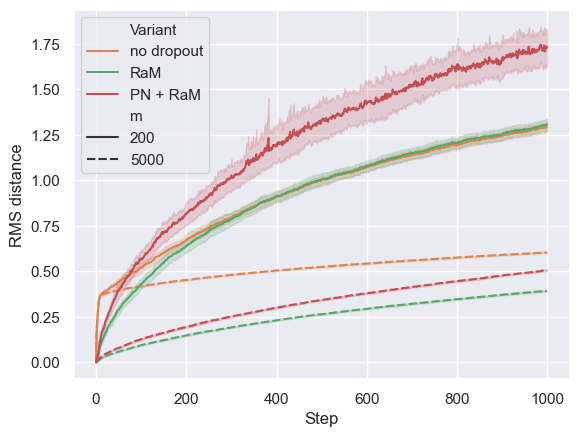

In [ ]:
selected_list_m = [200, 5_000]
selected_list_m_df = distance_df[distance_df["m"].isin(selected_list_m)]
sns.lineplot(selected_list_m_df, x="Step", y="RMS distance", style="m", hue="Variant", palette=[sns.color_palette()[1], sns.color_palette()[2], sns.color_palette()[3]])
plt.savefig("figures/distance_traj_time_lin.pdf", bbox_inches="tight")
plt.show()

### As a function of width

Log-log plot

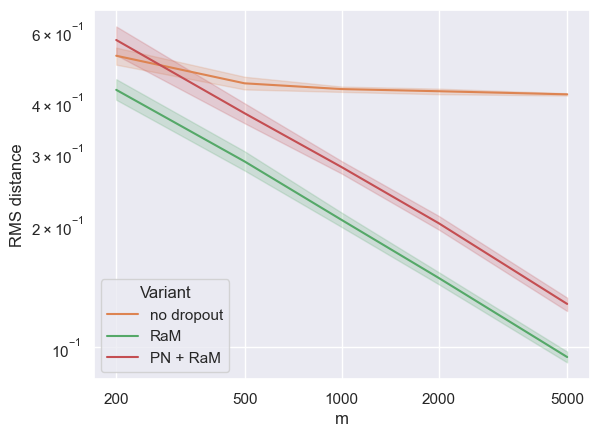

In [20]:
selected_step = 100
sns.lineplot(distance_df[distance_df["Step"] == selected_step], x="m", y="RMS distance", hue="Variant", palette=[sns.color_palette()[1], sns.color_palette()[2], sns.color_palette()[3]])
plt.xscale('log')
plt.yscale('log')
plt.xticks([200, 500, 1_000, 2_000, 5_000], [200, 500, 1_000, 2_000, 5_000])
plt.savefig("figures/distance_traj_width_log_log.pdf", bbox_inches="tight")
plt.show()